# PRCP-1001: **Rice Leaf Disease Detection using CNN**
**Made by:** **Chinmay Shastry**


# Project Documentation
# Index

1. [**Dataset Description and Data Analysis**](#Dataset-Description-and-Data-Analysis)
2. [**Data Preprocessing and Preparation**](#DataPreprocessing-and-Preparation)

    1. [***Basic Data Analysis***](#Basic-Data-Analysis)
    2. [***Data preprocessing***](#Data-preprocessing)
    3. [***Baseline Model***](#Baseline-Model)
3. [**Baseline Model Performance**](#Baseline-Model-Performance)
4. [**Data Augmentation**](#Data-Augmentation)
5. [**Improved CNN Model with Regularization**](#Improved-CNN-Model-with-Regularization)
6. [**Improved Model Performance**](#Improved-Model-Performance)
7. [**Final Model Recommendation**](#Final-Model-Recommendation)
8. [**Model Comparison**](#Model-Comparison)
9. [**Challenges Faced and Techniques Used**](#Challenges-Faced-and-Techniques-Used)
10. [**Conclusion**](#Conclusion)


## Introduction

Rice is one of the most important staple crops worldwide, and plant diseases can significantly reduce crop yield and quality. Early detection of rice leaf diseases helps farmers take timely action and minimize losses.

This project focuses on identifying major rice leaf diseases using image classification techniques and deep learning models. A Convolutional Neural Network (CNN) is used to automatically classify rice leaf images into different disease categories.

---
## Dataset Description and Data Analysis

The dataset used in this project contains **119 RGB images** of rice leaves affected by different diseases. The images are grouped into **three classes**, with **40, 40 & 39** images respectively.

### Disease Classes
- Leaf Smut  
- Brown Spot  
- Bacterial Leaf Blight  

Each image represents a diseased rice leaf, and the dataset was visually inspected to understand color patterns, texture variations, and lesion characteristics across different disease types.

Due to the small dataset size, statistical generalization is limited, and evaluation metrics may fluctuate with small variations in predictions. Therefore, results should be interpreted cautiously and considered exploratory rather than definitive.

---
## Data Preprocessing and Preparation

Before training the models, several preprocessing steps were applied to prepare the image data for deep learning:

- All images were `resized` to a fixed resolution of **128 × 128 pixels** to ensure `uniform` input dimensions.
- Pixel values were `rescaled` to the range **[0, 1]** to `normalize` the input data and improve model convergence.
- The dataset was split into **training (80%) and validation (20%)** subsets using a `directory-based split`.

Separate data generators were used for training and validation to ensure that the validation data remains unseen and unbiased during training.

### Importing Necessary Libraries

In [1]:
# Import necessary libraries
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
import random

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix

C:\Users\Admin\anaconda3\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\Admin\anaconda3\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\Admin\anaconda3\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/resource_handle.proto. Please update the gencode to avoid compatibility violations in t

In [2]:
# Set random seeds for reproducibility
seed = 42
tf.random.set_seed(seed)
np.random.seed(seed)
random.seed(seed)

In [3]:
# Extracting the dataset from the zip file
zip_path = 'RiceLeaf.zip'
extract_path = 'RiceLeaf'

if not os.path.exists(extract_path):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("Dataset extracted successfully.")
else:
    print("Dataset already extracted.")

Dataset already extracted.


In [4]:
# Contents list of the extracted directory
os.listdir(extract_path)

['Bacterial leaf blight', 'Brown spot', 'Leaf smut']

### Basic Data Analysis

In [5]:
# Count the number of images in each class folder

for folder in os.listdir(extract_path):
  class_path = os.path.join(extract_path, folder)
  print(folder, ":", len(os.listdir(class_path)))

Bacterial leaf blight : 40
Brown spot : 40
Leaf smut : 39


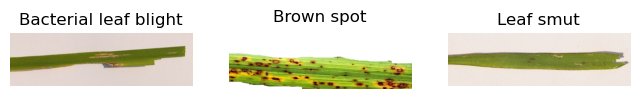

In [6]:
# Display sample images from each class

plt.figure(figsize=(8,6))

for i, folder in enumerate(os.listdir(extract_path)):
  img_path = os.path.join(extract_path, folder, os.listdir(os.path.join(extract_path, folder))[0])
  img = plt.imread(img_path)

  plt.subplot(1,3,i+1)
  plt.imshow(img)
  plt.title(folder)
  plt.axis("off")

plt.show()

In [7]:
# Summary of dataset characteristics
# The dataset contains 119 RGB images evenly distributed across three disease classes.
# Visual inspection shows clear texture and color differences among diseases.

### Data preprocessing

In [8]:
# Define image size and batch size for data processing
img_size = (128,128)
batch_size = 16

In [9]:
# Create data generators for training and validation without augmentation
# Train-Validation Generator (NO augmentation yet)

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = datagen.flow_from_directory(
    extract_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=seed
)

val_gen = datagen.flow_from_directory(
    extract_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=seed
)

Found 96 images belonging to 3 classes.
Found 23 images belonging to 3 classes.


### Baseline Model

In [10]:
# Define the architecture of the baseline CNN model
# Building a Simple CNN model

baseline_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(*img_size, 3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    GlobalAveragePooling2D(),
    
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')
])

C:\Users\Admin\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [11]:
# Compile the baseline CNN model
# Compile Model
baseline_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=["accuracy"]
)

In [12]:
# Define EarlyStopping callback to prevent overfitting
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [13]:
# Train the baseline CNN model
# Train the Model

history_baseline = baseline_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=[early_stop]
)

C:\Users\Admin\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.2812 - loss: 1.1039 - val_accuracy: 0.3478 - val_loss: 1.0956
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.3854 - loss: 1.0920 - val_accuracy: 0.3478 - val_loss: 1.0925
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.4479 - loss: 1.0907 - val_accuracy: 0.4783 - val_loss: 1.0873
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.5104 - loss: 1.0849 - val_accuracy: 0.5652 - val_loss: 1.0839
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.5104 - loss: 1.0793 - val_accuracy: 0.3913 - val_loss: 1.0833
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.5104 - loss: 1.0777 - val_accuracy: 0.4348 - val_loss: 1.0768
Epoch 7/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.4479 - loss: 1.0785 - val_accuracy: 0.3913 - val_loss: 1.0758
Epoch 8/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.5625 - loss: 1.0585 - val_accuracy: 0.3913 - val_loss: 1.0809
Epoch 9/30
6/6 

### Baseline model overfitting

1. The baseline CNN achieved high training accuracy but showed a noticeable gap between training and validation performance, indicating `overfitting`. 
2. This behavior is expected when training convolutional networks on small datasets with limited variability.

**Note on Data Augmentation**

1. A baseline CNN model was trained without augmentation. Data augmentation was later introduced to reduce overfitting.
2. A temporary drop in validation accuracy is expected on small datasets, as augmentation increases training difficulty while improving generalization.


**Important:** Only training data should be augmented.  
Validation data must reflect real, unseen images.


### Baseline Model Performance

The baseline CNN achieved reasonable training accuracy but showed signs of **overfitting**, with validation accuracy lagging behind training performance.

This behavior is expected due to:
- The small size of the dataset
- Limited variability in training images
- Lack of regularization techniques in the baseline model

The baseline model results highlight the need for techniques that improve generalization.


---
## Data Augmentation

Due to the limited size of the dataset, data augmentation was applied to artificially increase the diversity of training images. Data augmentation helps reduce overfitting by exposing the model to varied versions of the same images.

The following augmentation techniques were used:
- Small rotations
- Mild zooming
- Horizontal flipping

Augmentation parameters were kept conservative to avoid generating unrealistic leaf images. Importantly, **data augmentation was applied only to the training data**, while the validation data was left unchanged to ensure fair evaluation.


In [14]:
# Augmentation generator (training only)
aug_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=8,
    zoom_range=0.08,
    horizontal_flip=True,
    validation_split=0.2
)

In [15]:
# Validation generator (no augmentation)
val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [16]:
# Create new data generators with augmentation for training and without for validation

# Training generator (augmented)
train_aug_gen = aug_datagen.flow_from_directory(
    extract_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=seed
)

# Validation generator (clean)
val_aug_gen = val_datagen.flow_from_directory(
    extract_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=seed
)

Found 96 images belonging to 3 classes.
Found 23 images belonging to 3 classes.


## `Only training data should be augmented`

## Improved CNN Model with Regularization

To address the overfitting observed in the baseline model, an improved CNN architecture was developed with additional regularization techniques.

The improvements include:
- An additional convolutional layer for better feature extraction
- Batch Normalization to stabilize and speed up training
- Dropout to reduce reliance on specific neurons and improve generalization

These techniques help the model learn more robust patterns from a small dataset.


In [17]:
# Define the architecture of the improved CNN model with regularization layers

improved_model = Sequential([
    Conv2D(32, (3,3), activation='relu',input_shape=(*img_size, 3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3 ), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(), # This stabilizes training on small datasets.
    MaxPooling2D(2,2),

    GlobalAveragePooling2D(),

    Dense(32, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])

In [18]:
# Compile the improved CNN model

improved_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [19]:
# Train the improved CNN model with augmented data

history_aug = improved_model.fit(
    train_aug_gen,
    validation_data=val_aug_gen,
    epochs=30,
    callbacks=[early_stop]
)

Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 16s 2s/step - accuracy: 0.4896 - loss: 1.1574 - val_accuracy: 0.3478 - val_loss: 1.0997
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.6146 - loss: 0.8537 - val_accuracy: 0.3913 - val_loss: 1.0907
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.5938 - loss: 0.9169 - val_accuracy: 0.3478 - val_loss: 1.0879
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.6979 - loss: 0.7121 - val_accuracy: 0.3478 - val_loss: 1.0872
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.7500 - loss: 0.7195 - val_accuracy: 0.3478 - val_loss: 1.0837


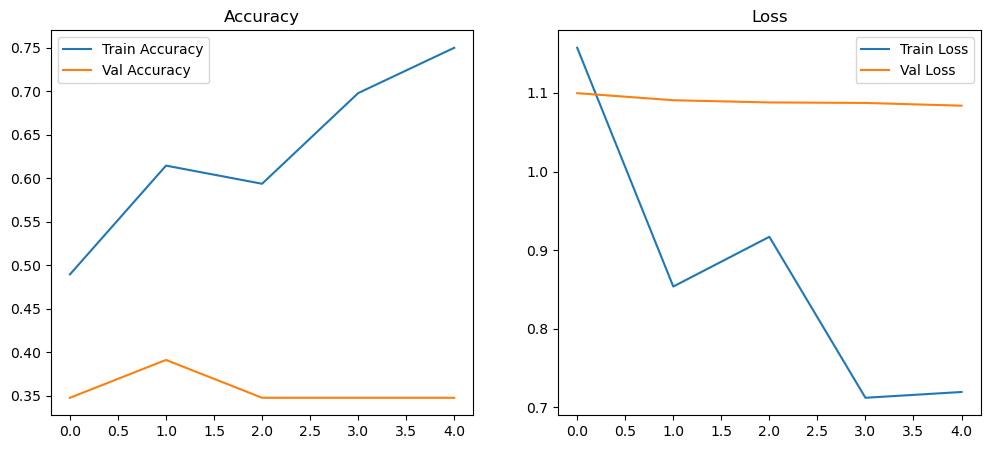

In [20]:
# Plot Learning Curves

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history_aug.history['accuracy'], label='Train Accuracy')
plt.plot(history_aug.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_aug.history['loss'], label='Train Loss')
plt.plot(history_aug.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.show()


In [21]:
# Validation Performance

val_loss, val_acc = improved_model.evaluate(val_aug_gen, verbose=0)

print("Validation Accuracy:", (val_acc * 100))
print("Validation Loss: ",(val_loss))


Validation Accuracy: 34.78260934352875
Validation Loss:  1.0996806621551514


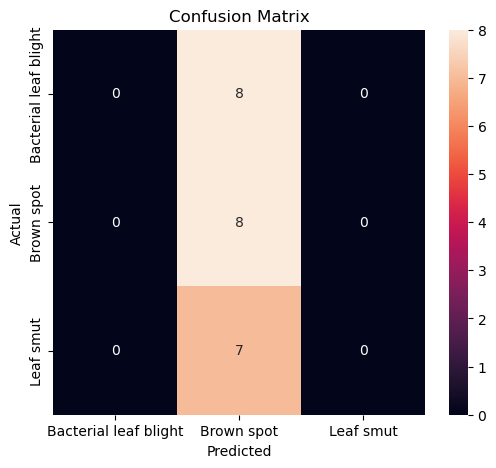

In [22]:
# Confusion Matrix

val_gen.reset()

predictions = improved_model.predict(val_aug_gen, verbose=0)
y_pred = np.argmax(predictions, axis=1)
y_true = val_gen.classes

class_names = list(val_gen.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [23]:
# Classification Report

print(classification_report(y_true, y_pred, target_names=class_names))

                       precision    recall  f1-score   support

Bacterial leaf blight       0.00      0.00      0.00         8
           Brown spot       0.35      1.00      0.52         8
            Leaf smut       0.00      0.00      0.00         7

             accuracy                           0.35        23
            macro avg       0.12      0.33      0.17        23
         weighted avg       0.12      0.35      0.18        23



C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


### Improved Model Performance

1. The improved CNN demonstrated more stable validation performance and a reduced gap between training and validation accuracy. 
2. While overall accuracy improvements may be modest due to dataset size constraints,
   the model exhibits better generalization behavior compared to the baseline model.

In [24]:
# Capture and display the final validation accuracies of both models

baseline_val_acc = max(history_baseline.history['val_accuracy'])
augmented_val_acc = max(history_aug.history['val_accuracy'])

baseline_val_acc, augmented_val_acc

(0.5652173757553101, 0.3913043439388275)

In [25]:
model_comparison = pd.DataFrame({
    "Model": [
        "Baseline CNN (No Augmentation)",
        "Improved CNN (With Data Augmentation)"
    ],
    "Best Validation Accuracy": [
        baseline_val_acc,
        augmented_val_acc
    ]
})

model_comparison

,Model,Best Validation Accuracy
0,Baseline CNN (No Augmentation),0.565217
1,Improved CNN (With Data Augmentation),0.391304


---
## Final Model Recommendation

1. Considering the limited dataset size, the `improved CNN model with augmentation and regularization` is `recommended` as the final model.
2. Although performance gains are moderate, the model shows improved generalization stability and reduced overfitting.
3. Future work should include collecting a larger dataset to enable stronger statistical validation.

---
## Model Comparison

Two CNN models were developed and evaluated in this project:

- **Baseline CNN (without data augmentation)**
- **Improved CNN (with data augmentation and regularization)**

The baseline CNN served as a reference model and showed signs of overfitting due to the small dataset size. The improved CNN incorporated data augmentation, batch normalization, and dropout to improve generalization.

A comparison of validation accuracy shows that the improved CNN provides more stable performance and better resistance to overfitting compared to the baseline model.


---
## Challenges Faced and Techniques Used

1. **Limited Dataset Size**  
   The dataset contains only 119 images, which increases the risk of overfitting.  
   *Technique used:* EarlyStopping, data augmentation, and regularization.

2. **Overfitting in Baseline Model**  
   The baseline CNN showed a clear gap between training and validation accuracy.  
   *Technique used:* Batch normalization and dropout layers.

3. **Instability with Aggressive Augmentation**  
   Strong augmentation initially reduced validation accuracy.  
   *Technique used:* Conservative augmentation parameters to preserve realistic image patterns.


---
## Conclusion

This project demonstrates the application of deep learning techniques for rice leaf disease detection using a small image dataset. Through careful model design, data augmentation, and regularization, a reliable classification model was developed.

The improved CNN model provides a practical solution for early disease detection, which can assist farmers and agricultural experts in improving crop health and productivity.
